# init

In [1]:
import os
import sys
import copy
import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
from scipy import stats
import importlib
import time
import tifffile as tf
import shutil
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
plt.rcParams['font.family']           = 'sans-serif'
plt.rcParams['font.sans-serif']       = ['Arial']
plt.rcParams['pdf.fonttype']          = 42       # embed fonts in PDF (Type 42)
plt.rcParams['axes.unicode_minus']    = False    # use ASCII minus sign
plt.rcParams['mathtext.default']      = 'regular'

#IMPORTANT two options for setting paths here:
#OPTION 1: Automatically determine the parent directory of the notebook's directory
# import ipynbname
# NOTEBOOK_PATH = ipynbname.path()
# PARENT_DIR = NOTEBOOK_PATH.parent.parent  # parent of the notebook's directory
# print("NOTEBOOK_PATH: " + str(NOTEBOOK_PATH))
# print("PARENT_DIR: " + str(PARENT_DIR))
#OPTION 2: Manually set PARENT_DIR if needed
PARENT_DIR = "/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR"
DATA_DIR = "/export/general/pooledData/Jackson/repo_data/"
figSaveDir = os.path.join(PARENT_DIR, "figurePanels", "Fig4")
PDF_export_active = False

#IMPORTANT: The following class and function are used to conditionally save figures to PDF based on the PDF_export_active flag. If PDF_export_active is True, figures will be saved to the specified path; if False, the savefig calls will be ignored.
class _NoPdf:
    """Null stand-in for PdfPages: accepts savefig calls and writes nothing."""
    def __enter__(self):        return self
    def __exit__(self, *exc):   return False
    def savefig(self, *args, **kwargs): pass

def maybe_pdf(path, active=None):
    active = PDF_export_active if active is None else active
    return PdfPages(path) if active else _NoPdf()

#IMPORTANT Load the manuscript functions
import js_manuscript_final as jsm

#OPTIONAL Load from specific directory if needed (uncomment the following lines)
# path = os.path.join(PARENT_DIR, "js_manuscript_final.py")
# spec = importlib.util.spec_from_file_location("jsm", path)
# jsm = importlib.util.module_from_spec(spec)
# spec.loader.exec_module(jsm)
# print(jsm.__file__)

#OPTIONAL Reload the module to ensure the latest version is used
%load_ext autoreload
%autoreload 2

# Modeled responses

In [2]:
def generate_dynamic_gcamp(duration_sec, fs, event_list, noise_std=0.05, baseline=1.0):
    """
    Generates GCaMP traces with event-specific kinetics and adjustable noise.
    
    Parameters:
    - duration_sec: Total time of recording
    - fs: Sampling frequency
    - event_list: List of dicts [{'t':, 'amp':, 'tr':, 'td':}]
    - noise_std: Standard deviation of Gaussian noise (higher = noisier)
    - baseline: The resting F0 value
    """
    t = np.arange(0, duration_sec, 1/fs)
    trace = np.zeros_like(t)
    
    for ev in event_list:
        # Extract parameters for this specific event
        t_start, amp = ev['t'], ev['amp']
        tau_r, tau_d = ev['tr'], ev['td']
        
        idx = np.searchsorted(t, t_start)
        if idx >= len(t): continue
        
        # Create kernel for this specific event
        # (Using 7x decay to ensure a very smooth return to baseline)
        k_t = np.arange(0, 7 * tau_d, 1/fs)
        kernel = (np.exp(-k_t / tau_d) - np.exp(-k_t / tau_r))
        
        if np.max(kernel) > 0:
            kernel = (kernel / np.max(kernel)) * amp
            
        # Add to the global trace
        clip = min(len(kernel), len(t) - idx)
        trace[idx : idx + clip] += kernel[:clip]

    # Apply the user-defined noise level
    noise = np.random.normal(0, noise_std, len(t))
    return t, trace + baseline + noise

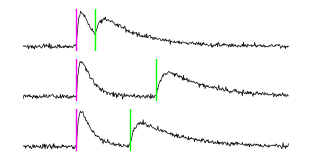

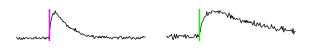

In [3]:
figName = "Fig4_model_responses.pdf"
duration_sec = 10
fs = 45
noise_std=0.05
baseline=1.0

eventColors = [(1,0,1),(0,1,0)]
with maybe_pdf(os.path.join(figSaveDir,figName)) as pdf:
    
    nRows = 3
    nCols = 1
    figSize = (3,1.5)
    fig,ax=jsm.clean_subplots(nRows,nCols,figsize=figSize,facecolor = 'none')
    events = [
        {'t': 2.0,  'amp': 1.5, 'tr': 0.1, 'td': 0.4},
        {'t': 2.7,  'amp': 1, 'tr': 0.2, 'td': 1.5}
    ]
    time, clean_signal = generate_dynamic_gcamp(duration_sec, fs, events, noise_std, baseline)
    row = 0
    ax[row].plot(time, clean_signal, color=(0,0,0),lw=0.5)
    for e0,e in enumerate(events):
        ax[row].axvline(e['t'],color = eventColors[e0],lw = 1)
    ax[row].set_xticks([])
    ax[row].set_yticks([])
    ax[row].spines[['top','right','bottom','left']].set_visible(False)
    events = [
        {'t': 2.0,  'amp': 1.5, 'tr': 0.1, 'td': 0.4},
        {'t': 5,  'amp': 1, 'tr': 0.2, 'td': 1.5}
    ]
    time, clean_signal = generate_dynamic_gcamp(duration_sec, fs, events, noise_std, baseline)
    row = 1
    ax[row].plot(time, clean_signal, color=(0,0,0),lw=0.5)
    for e0,e in enumerate(events):
        ax[row].axvline(e['t'],color = eventColors[e0],lw = 1)
    ax[row].set_xticks([])
    ax[row].set_yticks([])
    ax[row].spines[['top','right','bottom','left']].set_visible(False)
    events = [
        {'t': 2.0,  'amp': 1.5, 'tr': 0.1, 'td': 0.4},
        {'t': 4,  'amp': 1, 'tr': 0.2, 'td': 1.5}
    ]
    time, clean_signal = generate_dynamic_gcamp(duration_sec, fs, events, noise_std, baseline)
    row = 2
    ax[row].plot(time, clean_signal, color=(0,0,0),lw=0.5)
    for e0,e in enumerate(events):
        ax[row].axvline(e['t'],color = eventColors[e0],lw = 1)
    ax[row].set_xticks([])
    ax[row].set_yticks([])
    ax[row].spines[['top','right','bottom','left']].set_visible(False)
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page

    fig.set_facecolor((1,1,1))
    fig.set_alpha(1)
    
    
    
    duration_sec = 4
    nRows = 1
    nCols = 2
    figSize = (3,0.4)
    fig,ax=jsm.clean_subplots(nRows,nCols,figsize=figSize,facecolor = 'none')
    events = [
        {'t': 1.0,  'amp': 1.5, 'tr': 0.1, 'td': 0.4}
    ]
    time, clean_signal = generate_dynamic_gcamp(duration_sec, fs, events, noise_std, baseline)
    row = 0
    ax[row].plot(time, clean_signal, color=(0,0,0),lw=0.5)
    for e0,e in enumerate(events):
        ax[row].axvline(e['t'],color = eventColors[row],lw = 1)
    ax[row].set_xticks([])
    ax[row].set_yticks([])
    ax[row].spines[['top','right','bottom','left']].set_visible(False)
    events = [
        {'t': 1,  'amp': 1, 'tr': 0.2, 'td': 1.5}
    ]
    time, clean_signal = generate_dynamic_gcamp(duration_sec, fs, events, noise_std, baseline)
    row = 1
    ax[row].plot(time, clean_signal, color=(0,0,0),lw=0.5)
    for e0,e in enumerate(events):
        ax[row].axvline(e['t'],color = eventColors[row],lw = 1)
    ax[row].set_xticks([])
    ax[row].set_yticks([])
    ax[row].spines[['top','right','bottom','left']].set_visible(False)
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page

    fig.set_facecolor((1,1,1))
    fig.set_alpha(1)


# <font size="5">Load the exported example ROIs back out of the repo files

In [4]:
# comments indented under a '> only if ...' marker = used only when that other arg is active
# This is the only cell a repo-only rebuild of the figure needs — no pooled dataset, no
# sled_reImport_aligned_trace_data. The repo-facing notebooks (e.g. Fig4.ipynb) call the identical
# function as jsm.load_all_grouped_aligned_traces_split with the same arguments.
savePath = os.path.join(DATA_DIR,'examples','fig4_indiv_examples')  # directory holding the '_meta' and part files
saveName = 'fig4_indiv_examples'   # same base name passed to save_all_grouped_aligned_traces_split
groups = None                      # None -> every group saved; or list, e.g. ['goCue']
align_datas = None                 # None -> every align_data saved; or list, e.g. ['allTC_dffbc_decon_sp_events_MatchDx2Sx1']
anms = None                        # None -> every animal saved; or list of animal IDs
ROI_type_keys = None               # None -> all ROI types; or list, e.g. ['dendrites','somas']
ROI_scores = None                  # None -> all scores; or list, e.g. [1]
ROI_idxs = None                    # None -> all example ROIs; or list of ROI indices to keep
trace_types = None                 # None -> every trace_type saved; or list of trace_types to keep
extension = '.pkl'              # '.pkl.gz' | '.pkl.xz' | '.pkl.bz2' | '.pkl'  (extension used when the files were written)
restore_float_dtype = 'float32'    # None -> keep the stored dtype; or 'float32' to cast float16 traces back up
verbose = True                     # True | False  (prints each part file loaded)
all_grouped_aligned_traces_repo, cueInfo_repo, summaryInfo_repo = jsm.load_all_grouped_aligned_traces_split(
    savePath, saveName, groups=groups, align_datas=align_datas, anms=anms, ROI_type_keys=ROI_type_keys, 
    ROI_scores=ROI_scores, ROI_idxs=ROI_idxs, trace_types=trace_types, extension=extension, restore_float_dtype=restore_float_dtype, verbose=verbose)

# The trace_types actually present in the loaded repo data. The re-plot cell below pins
# figParams['trialGrouping'] to this, so what gets plotted can never drift from what was exported.
repo_trace_types = []
for g in all_grouped_aligned_traces_repo:
    for ad in all_grouped_aligned_traces_repo[g]['grouped_aligned_traces']:
        traces = all_grouped_aligned_traces_repo[g]['grouped_aligned_traces'][ad].get('aligned_traces',{})
        for a in traces:
            for rt in traces[a]:
                for sc in traces[a][rt]:
                    for ri in traces[a][rt][sc]:
                        for t in traces[a][rt][sc][ri]:
                            if t not in repo_trace_types:
                                repo_trace_types.append(t)
# 'bySess_byTtype' only rides along as session support, so it is not a trace_type to plot on its own.
# These are STORED branch names: a figure trace_type of 'preShiftOnly_byTtype' reads 'byPrePost_byTtype'.
repo_trace_types = [t for t in repo_trace_types if t != 'bySess_byTtype'] or repo_trace_types
print(f"trace_types (stored branches) available in the repo data: {repo_trace_types}")

load_all_grouped_aligned_traces_split: savePath='/export/general/pooledData/Jackson/repo_data/examples/fig4_indiv_examples' saveName='fig4_indiv_examples' groups=None align_datas=None anms=None ROI_type_keys=None ROI_scores=None ROI_idxs=None trace_types=None
  + loaded fig4_indiv_examples_meta.pkl  (2.99 MB)
  = cueInfo: loaded from metadata file | summaryInfo: loaded from metadata file
  + loaded fig4_indiv_examples_traces_goCue_allTC_dffbc_decon_sp_events_MatchDx2Sx1_B00002121774_dendrites_1_ROI48.pkl  (0.71 MB)
  + loaded fig4_indiv_examples_traces_goCue_allTC_dffbc_decon_sp_events_MatchDx2Sx1_B00002121774_somas_1_ROI19.pkl  (0.62 MB)
  = ['goCue']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['B00002121774']['dendrites'][1][48]: trace_types ['byPrePost_byTtype', 'bySess_byTtype']
  = ['goCue']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['B00002121774']['somas'][1][19]: trace_types ['byPrePost_byTtype', 'bySess_byTtype']
trace_types (stored branches) available in the repo data: ['byPre

In [5]:
# comments indented under a '> only if ...' marker = used only when that other arg is active
# Small manifest of the per-example scalars trial_alignments_byROI_pages needs beyond the traces
# themselves (identifying indices + cosmetic page/cluster label text) — written by the export cell in
# Fig4_indiv_examples.ipynb, loaded here so this repo-only notebook never needs ROI_clustering (a
# clustering-run object that never ships to the repo).
import json
manifest_path = os.path.join(savePath, saveName+'_ROI_manifest.json')  # written by the export cell in Fig4_indiv_examples.ipynb
with open(manifest_path,'r') as f:
    ROI_manifest = json.load(f)
print(f"Loaded {len(ROI_manifest)} example ROI(s) from {manifest_path}")

Loaded 2 example ROI(s) from /export/general/pooledData/Jackson/repo_data/examples/fig4_indiv_examples/fig4_indiv_examples_ROI_manifest.json


In [6]:
figParams = {}
figParams['cueInfo'] = cueInfo_repo
zoom_s = 6
group = 'goCue'
group_label = 'AllTraceTypes_SDNorm'
trialGroupings = ['preShiftOnly_byTtype']
trialGrouping_labels = ['PreShift']
plotSets = ["CLR_ILR"]
figParams['export_align_data'] = ['allTC_dffbc_decon_sp_events_MatchDx2Sx1'] 
figParams['export_align_data_labels'] = ['sp_eventD2S1'] 

########################################################
figParams['plot_stat'] = 'summaryStats'
tg = 0
trialGroup = trialGroupings[tg]
trialGrouping_label = trialGrouping_labels[0]
ps = plotSets[0]
a = 0
align_data = figParams['export_align_data'][a]
figParams['align_data'] = align_data
figParams['align_data_label'] = figParams['export_align_data_labels'][a]
figParams['formatMode'] = 'vert'
figParams['examples_group'] = group
figParams['trialGrouping'] = trialGroup
figParams['trial_group_label'] = trialGrouping_labels[tg]
figParams['horzCueLineOn'] = True
figParams['horzCuePlotScalar'] = 0.03
figParams['horzCueImScalar'] = 0.01
figParams['line_colors_right']=[[0,0,1],[0,0,0.5]]
figParams['line_colors_left']=[[1,0,0],[0.5,0,0]]
figParams['addSpacers'] = True
figParams['dayLabels'] = True
figParams['sess_cmap'] = 'tab10'
figParams['export_ROI_type_keys'] = ['dendrites','somas']                       # 'dendrites','somas'
figParams['export_ROI_scores'] = [1]                              # 1,-1,0
figParams['shiftDay_nTrials'] = 100
figParams['shiftTrial_color'] = (1,0,0)
figParams['shiftTrial_lineStyle'] = ':'
figParams['shiftTrial_lineWidth'] = 1
figParams['shiftTrial_alpha'] = 0.3
figParams['yTicksOn'] = False
figParams['match_trial_counts'] = True
figParams['match_trial_ticks'] = 50
figParams['minRepeats_forYLim'] = 5 #to contribute to max/min caCLs
figParams['plotScalar']=0
figParams['scale_font'] = 10
figParams['facecolors_generic']=[[1,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_right']=[[0,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_left']=[[1,0,0],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors']=[[1,0,1],[1,1,0.5],[0.5,0.5,0.5]]
figParams['patch_alpha'] = 0.2
figParams['alpha']=0.5
figParams['edgecolor']='none'
figParams['imshow_lineWidth'] = 0.5


aaronCmap = {}
aaronCmap['type'] = 'smooth_diverging'
aaronCmap['cmap2'] = "gray"
aaronCmap['cmap1'] = "inferno"
aaronCmap['cutoff'] = 0.85
aaronCmap['center_width'] = 0.3
aaronCmap['minVal'] = 0.5
aaronCmap['maxVal'] = 0.9

figParams['cmap'] = aaronCmap
figParams['nan_color'] = (0.3,0.3,0.3)
figParams['horzScalar'] = 10
figParams['horzScalar_im'] = 10
figParams['horzScalar_zoom'] = 10
figParams['horzScalar_im_zoom'] = 3.4
figParams['vertScalar'] = 3
figParams['vertScalar_im'] = 3
figParams['vertScalar_zoom'] = 3
figParams['vertScalar_im_zoom'] = 1
figParams['wspace'] = 0.03
figParams['hspace'] = 0.005

figParams['horz_scale']=1
figParams['horz_scale_label']=" s"
figParams['horz_scale_loc']='TL'
figParams['vert_scale_loc']='TL'

##############################
figParams['plot_scaleBar']={}
figParams['plot_scaleBar']['length_s'] = 1
figParams['plot_scaleBar']['corner']='BR'
figParams['plot_scaleBar']['height_per'] = 0.3
figParams['plot_scaleBar']['lw'] = 1
figParams['plot_scaleBar']['vertAdjust']=0.25
figParams['plot_scaleBar']['horzAdjust']=0.1
figParams['plot_scaleBar']['fontsize'] = 8
figParams['plot_scaleBar']['includeLabel'] = False
##############################
figParams['im_scaleBar']={}
figParams['im_scaleBar']['corner']='TR'
figParams['im_scaleBar']['height_per'] = 0.3
figParams['im_scaleBar']['vertUnit'] = ' Trials'
figParams['im_scaleBar']['horzUnit'] = 's'
figParams['im_scaleBar']['manual_height'] = 100
figParams['im_scaleBar']['lw'] = 1
figParams['im_scaleBar']['vertAdjust']=0.2
figParams['im_scaleBar']['horzAdjust']=0.1
figParams['im_scaleBar']['fontsize'] = 8
figParams['im_scaleBar']['includeLabel'] = False

##############################
figParams['nan_empty_trials'] = True
figParams['plot_error'] = True

figParams['plot_key_main'] = 'boot_mean'
figParams['plot_key_error_pos'] = 'boot_std' #'sem'
figParams['plot_key_error_neg'] = 'boot_std' #'sem'
figParams['plot_key_label'] = "Trial Bootstrap\nMean (STD)"
figParams['plot_label'] = "TrialBootMeanSTD"

figParams['imshow_lineColor'] = (0,0,0)
figParams['window_lineColor'] = (0,0.75,0.75)
figParams['nSpacers'] = 3
figParams['endSpacer'] = False
figParams['tickSpacing_fr'] = 50
figParams['colorScalar'] = 1000
##############################
figParams,zoom = jsm.zoom_lookup(zoom_s,figParams)
##############################
figParams['vertUpperPlotBuffer'] = 0.02
figParams['vertLowerPlotBuffer'] = 0.01
figParams['manual_plotLims'] = False
figParams['manual_imCont'] = False
figParams['highImCont'] = {}
figParams['lowImCont'] = {}
figParams['highNormImCont'] = {}
figParams['lowNormImCont'] = {}
figParams['highDeltaImCont'] = {}
figParams['highROIImCont'] = {}
figParams['lowROIImCont'] = {}
figParams[align_data] = {}
figParams[align_data]['highROIImCont'] = {}
figParams[align_data]['lowROIImCont'] = {}
figParams[align_data]['nan_empty_trials'] = False
figParams[align_data]['revert_mask'] = True
figParams[align_data]['maxPer'] = 100
figParams[align_data]['highROIImCont']['dendrites'] = 0.05
figParams[align_data]['lowROIImCont']['dendrites'] = 0
figParams[align_data]['highROIImCont']['somas'] = 0.05
figParams[align_data]['lowROIImCont']['somas'] = 0
figParams['highCont'] = 0.9
figParams['minPer'] = 0
figParams['lowCont'] = 1
figParams['highImCont']['dendrites'] = []
figParams['lowImCont']['dendrites'] = []
figParams['highNormImCont']['dendrites'] = []
figParams['lowNormImCont']['dendrites'] = []
figParams['highDeltaImCont']['dendrites'] = []
figParams['highImCont']['somas'] = []
figParams['lowImCont']['somas'] = []
figParams['highNormImCont']['somas'] = []
figParams['lowNormImCont']['somas'] = []
figParams['highDeltaImCont']['somas'] = []

figParams['highImCont']['dendrites'].append(0.001)
figParams['lowImCont']['dendrites'].append(0)
figParams['highNormImCont']['dendrites'].append(0.3)
figParams['lowNormImCont']['dendrites'].append(0)
figParams['highDeltaImCont']['dendrites'].append(0.1)
figParams['highImCont']['somas'].append(0.005)
figParams['lowImCont']['somas'].append(0)
figParams['highNormImCont']['somas'].append(0.8)
figParams['lowNormImCont']['somas'].append(0)
figParams['highDeltaImCont']['somas'].append(0.1)
figParams['expanding_lineColor'] = (0.5,0.5,0.5)
figParams['expanding_lineStyle'] = '-'
figParams['expanding_lineWidth'] = 1
figParams['expanding_lineAlpha'] = 0.5
figParams['expanding_lineColor'] = (0.5,1,0)

figParams['scaling_be'] = ['preShift','postShift']
if 'preShiftOnly' in trialGroup:
    figParams['scaling_be'] = ['preShift']
if 'postShiftOnly' in trialGroup:
    figParams['scaling_be'] = ['postShift']

figParams['nan_empty_trials'] = figParams[align_data]['nan_empty_trials']
figParams['revert_mask'] = figParams[align_data]['revert_mask']
figParams['maxPer'] = figParams[align_data]['maxPer']
figParams['highROIImCont'] = figParams[align_data]['highROIImCont']
figParams['lowROIImCont'] = figParams[align_data]['lowROIImCont']

figParams['constrained_layout'] = True
figParams['dayLabels'] = True
figParams['clean'] = True
figParams['facecolor'] = 'none'
# figParams['facecolor'] = (1,1,1)
figParams['yTicksOn']= False
figParams['legendLoc'] = 'upper right'
figParams['legendBboxToAnchor'] = (1, 1)
figParams['legendFontsize'] = 8
figParams['legendReversed'] = True
figParams['lineWidth'] = 0.5
figParams['export_byPrePost_ttype_colors'] = {}
figParams['export_byPrePost_ttype_colors']['preShift'] = [(0.5,0,0),(0,0,0.5)]
figParams['export_byPrePost_ttype_colors']['postShift'] = [(1,0,0),(0,0,1)]
if 'ShiftOnly' in trialGroup:
    figParams['addSpacers'] = False
    figParams['export_byPrePost_ttype_colors']['preShift'] = [(1,0,0),(0,0,1)]
    figParams['export_byPrePost_ttype_colors']['postShift'] = [(1,0,0),(0,0,1)]
figParams['plot_horzCueLocation'] = 'bottom'
figParams['im_horzCueLocation'] = 'top'


Zoom mode activated: 6sZOOM
          xlim_zoom: {'trialStart': [-0.4, 6.2], 'goCue': [-3.1, 3.1], 'cTimes': [-3.1, 3.1], 'postContLick1': [-3.1, 3.1]}
        xticks_zoom: {'trialStart': [0, 1, 2, 3, 4, 5, 6], 'goCue': [-3, -2, -1, 0, 1, 2, 3], 'cTimes': [-3, -2, -1, 0, 1, 2, 3], 'postContLick1': [-3, -2, -1, 0, 1, 2, 3]}


Adding anmIdx 1 B00002121774 dendrites ROI_score 1 ROI24 ROI_idx 48 pg14...nRows: 5, nCols: 2, nPlots 1, figSize: (5.5, 8.75)
Calculating summary stats for filtered traces for anmIdx 1 B00002121774 dendrites ROI_score 1 ROI24 ROI_idx 48 pg14 behavior_epoch preShift ttype CL...Finished!
Calculating summary stats for filtered traces for anmIdx 1 B00002121774 dendrites ROI_score 1 ROI24 ROI_idx 48 pg14 behavior_epoch preShift ttype CR...Finished!
Calculating summary stats for filtered traces for anmIdx 1 B00002121774 dendrites ROI_score 1 ROI24 ROI_idx 48 pg14 behavior_epoch preShift ttype IL...Finished!
Calculating summary stats for filtered traces for anmIdx 1 B00002121774 dendrites ROI_score 1 ROI24 ROI_idx 48 pg14 behavior_epoch preShift ttype IR...Finished!
Current plotminVal: -0.027 plotmaxVal: 2.470 plotShift: [0. 0. 0. 0.]
Applying Manual Plot Limits
Final plotminVal: -3.500 final_plotmaxVal: 1.500 final_plotShift: [0, 0, 3, 3]
Finished!


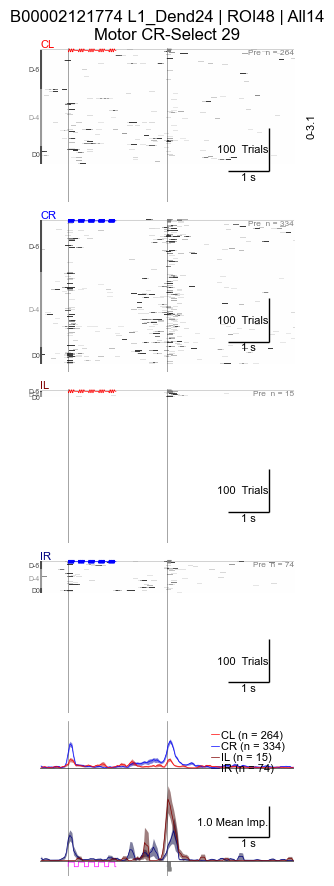

Adding anmIdx 1 B00002121774 somas ROI_score 1 ROI19 ROI_idx 19 pg79...nRows: 5, nCols: 2, nPlots 1, figSize: (5.5, 8.75)
Calculating summary stats for filtered traces for anmIdx 1 B00002121774 somas ROI_score 1 ROI19 ROI_idx 19 pg79 behavior_epoch preShift ttype CL...Finished!
Calculating summary stats for filtered traces for anmIdx 1 B00002121774 somas ROI_score 1 ROI19 ROI_idx 19 pg79 behavior_epoch preShift ttype CR...Finished!
Calculating summary stats for filtered traces for anmIdx 1 B00002121774 somas ROI_score 1 ROI19 ROI_idx 19 pg79 behavior_epoch preShift ttype IL...Finished!
Calculating summary stats for filtered traces for anmIdx 1 B00002121774 somas ROI_score 1 ROI19 ROI_idx 19 pg79 behavior_epoch preShift ttype IR...Finished!
Current plotminVal: -0.037 plotmaxVal: 3.411 plotShift: [0. 0. 0. 0.]
Applying Manual Plot Limits
Final plotminVal: -3.600 final_plotmaxVal: 4.500 final_plotShift: [0, 0, 3, 3]
Finished!


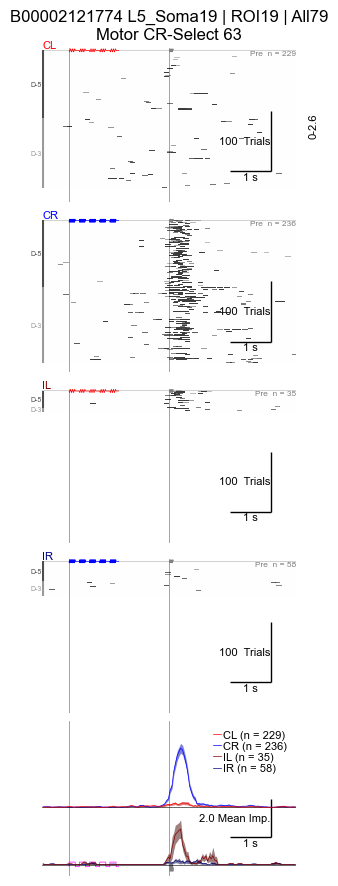

In [7]:
figName = 'Fig4_examples.pdf'
figParams['plot_figSummary_label'] = figParams['plot_stat']
figParams['export_ttypes'] = ['CL','CR','IL','IR'] 
figParams['export_ttype_colors'] = [(1,0,0),(0,0,1),(0.5,0,0),(0,0,0.5)]
figParams['scaling_ttypes'] = ['CL','CR','IL','IR']         
figParams['autoScale_ttypes'] = figParams['scaling_ttypes']
figParams['autoScale_be_ttypes'] = figParams['scaling_ttypes']
figParams['export_byPrePost_ttype_colors'] = {}
figParams['export_byPrePost_ttype_colors']['preShift'] = [(1,0,0),(0,0,1),(0.5,0,0),(0,0,0.5)]
figParams['export_byPrePost_ttype_colors']['postShift'] = [(1,0,0),(0,0,1),(0.5,0,0),(0,0,0.5)]
if 'ShiftOnly' in trialGroup:
    figParams['addSpacers'] = False
    figParams['export_byPrePost_ttype_colors']['preShift'] = [(1,0,0),(0,0,1),(0.5,0,0),(0,0,0.5)]
    figParams['export_byPrePost_ttype_colors']['postShift'] = [(1,0,0),(0,0,1),(0.5,0,0),(0,0,0.5)]
figParams['filt_trace_byTrial'] = True
figParams['filt_trace_byTrial_window'] = {}
figParams['filt_trace_byTrial_window']['allTC_dffbc_decon_sp_events_MatchDx2Sx1'] = {}
figParams['filt_trace_byTrial_window']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['dendrites'] = 3
figParams['filt_trace_byTrial_window']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['somas'] = 3
figParams['horzScalar_im_zoom'] = 2.75
figParams['vertScalar_im_zoom'] = 1.75
figParams['wspace'] = 0
figParams['hspace'] = 0
figParams['manual_plotmaxVal'] = {}
figParams['manual_plotminVal'] = {}
figParams['manual_plotShift'] = {}

figParams['plot_y0'] = 0.0
figParams['plot_height'] = 0.2

figParams['preview_figs'] = False
figParams['close_all_figs'] = False
saveFigs = PDF_export_active
verbose =True

figSaveDir = "/export/general/pooledData/Jackson/JS_figsPanels/Fig4"

with maybe_pdf(os.path.join(figSaveDir,figName)) as pdf:
    for e,entry in enumerate(ROI_manifest):
        if e == 0:
            figParams['manual_plotLims'] = True
            figParams['manual_plotmaxVal'][entry['ROI_type_key']] = 1.5
            figParams['manual_plotminVal'][entry['ROI_type_key']] = -3.5
            figParams['manual_plotShift'][entry['ROI_type_key']] = [0,0,3,3]
        else:
            figParams['manual_plotLims'] = True
            figParams['manual_plotmaxVal'][entry['ROI_type_key']] = 4.5
            figParams['manual_plotminVal'][entry['ROI_type_key']] = -3.6
            figParams['manual_plotShift'][entry['ROI_type_key']] = [0,0,3,3]

        pdf = jsm.trial_alignments_byROI_pages(pdf, summaryInfo_repo, \
            all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['traceAlignParams'],\
            all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['aligned_traces'], \
            figParams, figParams['trialGrouping'], align_data, zoom, figParams['export_ttypes'], \
            entry['ROI_score'], entry['ROI_type_key'], entry['anmIdx'], entry['anm'], entry['ROI_idx'], \
            entry['page_count'], entry['cluster_label'], entry['cluster_idx'], saveFigs, verbose)


# Load all data

In [8]:
#IMPORTANT Load the masterData dictionary, preferably from the data repo reduced file size versions
masterData = jsm.masterData_loading(DATA_DIR)
# mdDir = '/home/range6-raid3/scheij/Documents/Data/mainDS'
# mdTitle = 'allSlim3'
# masterData = pickle.load(open(fr'{mdDir}/{mdTitle}.p', 'rb'))

#General params
trialStart = 0.15
sampleEnd = trialStart+1.2
delayEnd = sampleEnd+1.25
anatKeys = ['dendrites', 'somas']
frs = [44.6, 22.8]
anms = list(masterData.keys())


--------------------------
Loading data for B00002121749...
Loading behavior data for B00002121749...
  Path: /export/general/pooledData/Jackson/repo_data/B00002121749/behavior
  File: B00002121749_behavior.pkl
  FileSize:      0.07 GB (0.06 GiB)
  Last Modified: 2026-08-07 15:06:11.098137
  Loading B00002121749_behavior.pkl from /export/general/pooledData/Jackson/repo_data/B00002121749/behavior...Finished!
  Loading Took a total of : 0.004 min
Loading shiftInfo data for B00002121749...
Loading somas data for B00002121749...
  Path: /export/general/pooledData/Jackson/repo_data/B00002121749/somas
  File: B00002121749_somas.pkl
  FileSize:      0.0 GB (0.0 GiB)
  Last Modified: 2026-08-07 15:06:11.109137
  Loading B00002121749_somas.pkl from /export/general/pooledData/Jackson/repo_data/B00002121749/somas...Finished!
  Loading Took a total of : 0.0 min
Loading session 0 data for B00002121749...
  Path: /export/general/pooledData/Jackson/repo_data/B00002121749/somas
  File: B00002121749_so

In [9]:
for anm in masterData:
    for field in ['somas','dendrites']:
        if 'dict' in str(type(masterData[anm][field])):
            for sess in masterData[anm][field]['sessions']:
                tf = masterData[anm][field]['sessions'][sess]['trial_frames']
                mx = max(np.nanmax(t) for t in tf if np.size(t))
                nn = sum(int(np.isnan(np.asarray(t, float)).any()) for t in tf)
                print(f"{anm} {field} s{sess}: max frame={mx:.0f} (int16 limit 32767), trials w/ NaN={nn}")


B00002121749 somas s0: max frame=77139 (int16 limit 32767), trials w/ NaN=0
B00002121749 somas s1: max frame=90359 (int16 limit 32767), trials w/ NaN=0
B00002121749 somas s2: max frame=122954 (int16 limit 32767), trials w/ NaN=0
B00002121749 somas s3: max frame=111482 (int16 limit 32767), trials w/ NaN=0
B00002121749 somas s4: max frame=122226 (int16 limit 32767), trials w/ NaN=0
B00002121774 somas s0: max frame=106329 (int16 limit 32767), trials w/ NaN=0
B00002121774 somas s1: max frame=95005 (int16 limit 32767), trials w/ NaN=0
B00002121774 somas s2: max frame=124589 (int16 limit 32767), trials w/ NaN=0
B00002121774 somas s3: max frame=103897 (int16 limit 32767), trials w/ NaN=0
B00002121774 somas s4: max frame=115306 (int16 limit 32767), trials w/ NaN=0
B00002121774 dendrites s0: max frame=160452 (int16 limit 32767), trials w/ NaN=0
B00002121774 dendrites s1: max frame=257959 (int16 limit 32767), trials w/ NaN=0
B00002121774 dendrites s2: max frame=299749 (int16 limit 32767), trials

/tmp/ipykernel_982605/875539283.py:6: RuntimeWarning: All-NaN slice encountered
  mx = max(np.nanmax(t) for t in tf if np.size(t))


In [ ]:
dffKey = 'impulse_trace'##'consensus_NMFtc_dff_bc_decon_sp'#'consensus_NMFtc_dff_bc'
dffKeys = ['impulse_trace']#['consensus_NMFtc_dff_bc_decon_sp', 'consensus_NMFtc_dff_bc', 'impulse_trace']
maskKey = 'trace_mask'

factors = [4,2]
Z = 'std_only'
phases2 = ['pre', 'preShift_early', 'preShift_late', 'post', 'late', 'day-1_beg', 'day-1_mid', 'day-1_end', 'shiftDay_post', 'shiftDay_pre', 'early'] 
windowSize = [-3.6,3.6]
importlib.reload(jsm)
allAnmParams = jsm.get_allAnmParams(masterData, anms, frs, factors, Z, phases2, dffKeys, maskKey=maskKey, windowSize = windowSize)


0 B00002121749
Getting params for somas impulse_trace
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


In [ ]:
thrsh = 0.05
minTrials = 5
anatKeys = ['dendrites', 'somas']
aAnms, keepRoisFull, keepRoisDS, allNaNs = jsm.check_anms_ROIs(allAnmParams, anms, anatKeys, dffKey, thrsh)
aAnms, iAnms, anmsMinTrial, allMinTrials = jsm.check_trials(allAnmParams, anms, anatKeys, dffKey, minTrials)
for ak, anat in enumerate(anatKeys):
    for anm in iAnms[anat]:
        print(f'{anm} {anat} keepRoisDS #ROIs: {np.sum(keepRoisDS[anat][anm])}')

In [ ]:
import dask
from dask.distributed import Client
from dask.distributed import LocalCluster
import dask.array as da
dask.config.set(temporary_directory='/export/disk1/aaron/')
dask.config.set({'logging.distributed': 'error'})
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 
cluster = LocalCluster(n_workers=4,threads_per_worker=8,memory_limit="20GiB") 
client=Client(cluster)

# go/contact

In [ ]:
allGC_orig = {}
for ak, anat in enumerate(anatKeys):
    F = frs[ak]/factors[ak]
    anatGC = {'go': [], 'contact': []}
    ROIcount = 0
    anmCount = 0
    for anm in iAnms[anat]:
        
        anmData = allAnmParams[anm]
        tsep = anmData[dffKey]['dsTsep'][anat]['go-psTsep']#[:,:,:maxFr]
        tracker = anmData['tracker']
        if ak ==0:
            anatMask = anmData['dendDays']
        else:
            anatMask = ~anmData['dendDays']
            
        cTimes = anmData['cTimes'][anatMask]+1
        aTkr = tracker[anatMask,:]
        cTimesFr = (cTimes-3.6)*F
        
        keepMask = np.logical_and(cTimesFr<80, np.isfinite(cTimesFr))
        keepMask = np.logical_and(keepMask, aTkr[:,0]<0)
        ctfBase = cTimesFr[keepMask].astype(int)
        tsep2 = tsep[keepMask,:,:]
        tsep2 = tsep2[:,keepRoisDS[anat][anm],:]
        nRoi = tsep2.shape[1]
        if nRoi > 0:
            ROIcount+=nRoi
            anmCount+=1
        print(f'{anm} {anat} nROIs: {nRoi}')
        nTime = tsep2.shape[2]
        anmStuff = []

        for t, ttype in enumerate([0,1]):

            ttypeMask = aTkr[keepMask,2]==ttype
            tsep_to_go = tsep2[ttypeMask,:,:]
            ctf = ctfBase[ttypeMask]

            irfs = client.map(jsm.get_go_contact_irf, [tsep_to_go[:,roi,:] for roi in range(tsep_to_go.shape[1])], ctf=ctf)
            
            irfs = client.gather(irfs)
            irfs = np.dstack(irfs)
            
            anmStuff.append(irfs)
        anatGC['go'].append(np.dstack([anmStuff[i][:,0,:] for i in range(2)])) #time, roi, side
        anatGC['contact'].append(np.dstack([anmStuff[i][:,1,:] for i in range(2)])) #time, roi, side
    allGC_orig[anat] = anatGC
    print(f'{anat} total anm {anmCount} total ROI {ROIcount}')


In [ ]:
avgCTimes = {}
allAnms = np.unique(np.hstack([iAnms[anat] for anat in anatKeys]))
for anm in allAnms:
    cTimes = allAnmParams[anm]['cTimes']+1
    tkr = allAnmParams[anm]['tracker']
    preMask = allAnmParams[anm]['shiftMask']['pre']
    fullMask = preMask
    pTkr = tkr[fullMask,:]
    pCt = cTimes[fullMask]
    
    avgCTimes[anm] = {}
    for t, ttype in enumerate(['right','left']):
        avgCTimes[anm][ttype] = np.nanmean(pCt[pTkr[:,2]==t])

global_avgCt = np.nanmean(np.hstack([np.nanmean([avgCTimes[anm]['right'] for anm in allAnms]),
                               np.nanmean([avgCTimes[anm]['left'] for anm in allAnms])]))

# realign contact to the global average CT
allGC = copy.deepcopy(allGC_orig)
for ak, anat in enumerate(anatKeys):
    F = frs[ak]/factors[ak]
    for a, anm in enumerate(iAnms[anat]):
        anmC = allGC[anat]['contact'][a] #time, roi, ttype
        cAligned = np.ones(anmC.shape)*np.NaN
        for t, ttype in enumerate(['right', 'left']):
            toFill = np.ones(anmC.shape[:-1])*np.NaN
            ct = avgCTimes[anm][ttype]
            dif = ct-3.6
            ctF = int(np.ceil(dif*F))
            toFill[ctF:,:] = anmC[:-ctF,:,t]
            cAligned[:,:,t] = toFill
        allGC[anat]['contact'][a] = cAligned

for anat in anatKeys:
    for tl in ['go','contact']:
        allGC[anat][tl] = np.hstack(allGC[anat][tl])

for anat in anatKeys:
    for tl in ['go','contact']:
        allGC_orig[anat][tl] = np.hstack(allGC_orig[anat][tl])

In [ ]:
# roi bootstrapps
nBoot = 10000
bsGC = {}
for anat in anatKeys:
    bsGC[anat] = {'go': [], 'contact': []}
    anatGC = allGC[anat]
    for t in range(2):
        goData = anatGC['go'][:,:,t]
        goBS = np.vstack([np.nanmean(goData[:,np.random.choice(np.arange(goData.shape[1]),goData.shape[1])], axis = 1) for i in range(nBoot)]) #boot x time
        bsGC[anat]['go'].append(goBS)

        ctData = anatGC['contact'][:,:,t]
        ctBS = np.vstack([np.nanmean(ctData[:,np.random.choice(np.arange(ctData.shape[1]),ctData.shape[1])], axis = 1) for i in range(nBoot)]) #boot x time
        bsGC[anat]['contact'].append(ctBS)

In [ ]:
figName = 'Fig4_go_v_contact_components.pdf'
fontsize = 8
figsize=(1.5,2)
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.25
)
ls = ['-','--']
aColors = ['c','m']
typeLabels = ['go','contact']

CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "boot. median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "boot. mean±SEM"
elif error == 'std':
    errorLabel = "boot. mean±SD"
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
tColors = [(0,0,1),(1,0,0)]
linewidth = .5

win2 = np.hstack([3.6,3.75])
win1 = np.hstack([1.2,1.7])
aLabels = ['Dendrites', 'Somas']
tLabels = ['Go','Contact']
ylim = [0.5,3]
xlim = [-1.25,2.5]

plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.4
plot_scaleBar['lw'] = 1
plot_scaleBar['vertAdjust']=0.5
plot_scaleBar['horzAdjust']=0.1
plot_scaleBar['fontsize'] = fontsize
plot_scaleBar['includeLabel'] = True
vertLabel = 'Act. Rel. to\nEarly Delay\n('+errorLabel+')'
vertLabel = 'Rel.\nActivity'
markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5

fig,axs=jsm.clean_subplots(2,1,figsize=figsize,facecolor='none',constrained_layout = False,gridspec_kw=gridspec_kw)

for ak,ax in enumerate(axs[:,0]):
    ax.axhline(1,lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
    ax.axvline(0, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)

for ak, anat in enumerate(anatKeys):
    F = frs[ak]/factors[ak]
    
    baseline = np.nanmean(np.nanmean(np.dstack(bsGC[anat]['go'])[:,(int(F*2.35)):(int(F*2.975)),:], axis = 1), axis = 1)
    allC = np.nanmean(np.dstack(bsGC[anat]['contact']), axis = 2)/baseline[:,None]
    allG = np.nanmean(np.dstack(bsGC[anat]['go']), axis = 2)/baseline[:,None]
    allTypes = [allG, allC]

    for i, typeLabel in enumerate(typeLabels):
        ax = axs[i,0]
        normed = allTypes[i]#/denom[:,None]
        mean = np.nanmean(normed,axis=0)
        med = np.nanmean(normed,axis=0)
        std = np.nanstd(normed,axis=0, ddof = 1)
        sem = std / np.sqrt(normed.shape[0])
        low,high = np.nanpercentile(normed, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std
        x = np.linspace(-3.6,3.6,len(mean))
        plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
        ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = aColors[ak], alpha = 0.5,edgecolor='none')
        ax.plot(x[plotIdx], mainPlot[plotIdx], color = aColors[ak], label = aLabels[ak],linewidth =linewidth)
for ak,ax in enumerate(axs[:,0]):
    if ak > 0:
        ax.set_xlabel('Time Rel. to Go Cue (s)',fontsize = fontsize)
    ax.text(xlim[0],ylim[1],tLabels[ak],fontsize = fontsize+2,ha='left',va='top')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ylim = ax.get_ylim()
    ax.fill_between([x[int(np.floor(win2[0]*F))],x[int(np.ceil(win2[1]*F))]], [ylim[0]]*2, [ylim[1]]*2, color = (0,0,0), alpha =  0.1,edgecolor='none')
    ax.spines[['top','bottom','left', 'right']].set_visible(False)
    ax,plot_scaleBar = jsm.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)
    ax.set_xticks([])
    ax.set_yticks([])
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,ax)


In [ ]:
figName = 'Fig4_go_v_contact_components_bar.pdf'
figsize = [0.6,2]
fontsize = 8
alpha = 0.01
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "boot. mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"
linewidth = .5
win2 = np.hstack([3.6,3.75])
win1 = np.hstack([1.2,1.7])
aLabels = ['Dendrites', 'Somas']
tLabels = ['Go','Contact']
ylims=[[0,4],[0,3.1]]
yticks=[[0,1,2,3,4],[0,1,2,3]]
testLS = ':'
testDashes = (5,1)
testLW = 1
testColor = (0,0,0)
testAlpha = 0.5
allStats = {}
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.25
)
fig,axs=jsm.clean_subplots(2,1,figsize=figsize,facecolor='none', sharey = False,sharex=True,gridspec_kw=gridspec_kw)

for ak, anat in enumerate(anatKeys):
    F = frs[ak]/factors[ak]    
    baseline = np.nanmean(np.nanmean(np.dstack(bsGC[anat]['go'])[:,(int(F*2.35)):(int(F*2.975)),:], axis = 1), axis = 1)
    allC = np.nanmean(np.dstack(bsGC[anat]['contact']), axis = 2)/baseline[:,None]
    allG = np.nanmean(np.dstack(bsGC[anat]['go']), axis = 2)/baseline[:,None]
    allTypes = [allG, allC]

    denom = (np.nanmean(allG[:,12:-12], axis=1)+np.nanmean(allC[:,12:-12], axis=1))/2

    allVals = []
    for i, typeLabel in enumerate(typeLabels):
        ax = axs[i,0]
        normed = allTypes[i]#/denom[:,None]
        allVals.append(np.nanmean(normed[:,int(np.ceil(win2[0]*F)):int(np.ceil(win2[1]*F))], axis= 1))
    allStats[anat] = np.vstack(allVals)
testLine = 1
for a, ax in enumerate(axs[:,0]):
    dData = allStats['dendrites'][a,:]
    sData = allStats['somas'][a,:]
    allD = [dData, sData]
    ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha, dashes=testDashes)
    for d, data in enumerate(allD):
        mean = np.nanmean(data,axis=0)
        med = np.nanmedian(data,axis=0)
        std = np.nanstd(data,axis=0, ddof = 1)
        sem = std / np.sqrt(data.shape[0])
        low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std
        ax.bar(d, mainPlot, color = aColors[d],width = 0.75)
        ax.plot([d,d],[errorLow,errorHigh], color = (0,0,0),lw = linewidth)

        tail1 = np.sum(data<testLine)/data.shape[0]
        tail2 = np.sum(data>testLine)/data.shape[0]
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        pText = jsm.pstar(pVal,inclP = False)
        print(f'{anatKeys[d]}, {tLabels[a]}, mean: {np.nanmean(data):.03f}, std: {np.nanstd(data):.03f}, pval: {pVal:.03f}')
        ax.text(d,errorHigh,pText,fontsize=fontsize,ha='center',va='bottom')
    print('')
    pVal = np.sum(sData<dData)/sData.shape[0]
    pText = jsm.pstar(pVal,inclP = False)
    print(f'{tLabels[a]} {pVal:.03f}')
    topLine = [3.8,2.8][a]
    ax.plot([0,1],[topLine, topLine], color = (0,0,0),lw = linewidth)
    ax.text(.5,topLine,pText,fontsize=fontsize,ha='center',va='bottom')
    ax.spines[['top','right']].set_visible(False)
    ylim = ax.get_ylim()
    ax.text(-4,ylim[1]+0.2,tLabels[a]+" ",fontsize=fontsize+2,ha='left',va='bottom')
    ax.set_ylabel('Activity Rel.\nto Early\nDelay',fontsize=fontsize)
    ax.set_ylim(ylims[a])
    ax.set_yticks(yticks[a])
    ax.set_xlim([-1,2])
    ax.set_xticks([0,1])
    ax.set_xticklabels(aLabels,fontsize=fontsize,rotation=30,ha='right',va='top',rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 2) #
    print('')
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,ax)


# SMO Prep
### Note that SMO refers to Sensory vs Motor/Choice vs Outcome/Reward

In [ ]:
dffKey = 'impulse_trace'##'consensus_NMFtc_dff_bc_decon_sp'#'consensus_NMFtc_dff_bc'
dffKeys = ['impulse_trace']#['consensus_NMFtc_dff_bc_decon_sp', 'consensus_NMFtc_dff_bc', 'impulse_trace']
maskKey = 'trace_mask'

factors = [10,5]
Z = 'std_only'
phases2 = ['pre', 'preShift_early', 'preShift_late', 'post', 'late', 'day-1_beg', 'day-1_mid', 'day-1_end', 'shiftDay_post', 'shiftDay_pre', 'early'] 
windowSize = [-3.6,3.6]
importlib.reload(jsm)
allAnmParams = jsm.get_allAnmParams(masterData, anms, frs, factors, Z, phases2, dffKeys, maskKey=maskKey, windowSize = windowSize)


In [ ]:
thrsh = 0.05
minTrials = 5
anatKeys = ['dendrites', 'somas']
aAnms, keepRoisFull, keepRoisDS, allNaNs = jsm.check_anms_ROIs(allAnmParams, anms, anatKeys, dffKey, thrsh)
aAnms, iAnms, anmsMinTrial, allMinTrials = jsm.check_trials(allAnmParams, anms, anatKeys, dffKey, minTrials)
for ak, anat in enumerate(anatKeys):
    for anm in iAnms[anat]:
        print(f'{anm} {anat} keepRoisDS #ROIs: {np.sum(keepRoisDS[anat][anm])}')

In [ ]:
for anat in list(iAnms.keys()):
    ROIcount = 0
    anmCount = 0
    for anm in iAnms[anat]:
        nRoi = np.sum(keepRoisDS[anat][anm])
        if nRoi > 0:
            ROIcount+=nRoi
            anmCount+=1
        print(f'{anm} {anat} nROIs: {nRoi}')
    print(f'{anat} total anm {anmCount} total ROI {ROIcount}')


In [ ]:
import dask
from dask.distributed import Client
from dask.distributed import LocalCluster
import dask.array as da
dask.config.set(temporary_directory='/export/disk1/scratch/dask')
dask.config.set({'logging.distributed': 'error'})
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

# import warnings
# warnings.filterwarnings("ignore") 
cluster = LocalCluster(n_workers=4,threads_per_worker=8,memory_limit="20GiB") 
client=Client(cluster)

# SMO Calcs

### pre compute important stuff

In [ ]:
phases = ['pre']
mods = ['GO','CT'] #alignTime and error shorthand used in some funcs later
alignTimes = ['goCues','cTimes']
preComp = {}
minTrial = 5
# dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
useDS = True
binary = False
# targets
s2 = [1,-1,1,-1] #CR, CL, IR, IL
m2 = [1,-1,-1,1]
o2 = [1,1,-1,-1]
y2 = [s2,m2,o2]
label=['s','m','o']
orthOrder=np.array([2,1,0])
fixedCDs=False#[[-2.6,-2.0],[-0.6,0],[2,3]]#in seconds Rel. to align time
importlib.reload(jsm)
for anat in list(iAnms.keys()):
    anmDict={}
    for anm in iAnms[anat]:
        print(anm+" "+anat)
        phaseDict={}
        for phase in phases:
            alignDict={}
            for alignT in alignTimes:
                codeDict={}
                for i,code in enumerate(y2):
                    io = list(range(3))
                    io.pop(i)
                    io = np.hstack([i]+io)
                    if np.any(fixedCDs):
                        fcds=[fixedCDs[x] for x in io]
                    else:
                        fcds=False
                    oc = copy.deepcopy(y2)
                    oc.pop(i)
                    # this will orthogonize according to a Rel. order
                    oo = copy.deepcopy(orthOrder)
                    # uncomment to generate a fixed order
                    codeDict[label[i]] = jsm.pullAnmTsepComputeSMOXval(allAnmParams, anm, anat, phase, frs, 
                                                                       alignT, factors, minTrial, code, keepRoisDS, keepRoisFull,
                                                                       ortho = oc, orthoOrder=oo,fixedCDs=fcds,dffKey = dffKey,useDS = useDS, binary=binary)
                alignDict[alignT]=codeDict   
            phaseDict[phase]=alignDict
        anmDict[anm]=phaseDict
    preComp[anat]=anmDict

In [ ]:
psWindow = [-3.6,3.6]
useDS = True
anmsToUse = iAnms
shuffAnms = True
shuffRois = False
enforceMinTrial = False
binary = False
label=['s','m','o']

allAnms = np.unique(np.hstack([anmsToUse[anat] for anat in anatKeys]))
phases = ['pre']
mods = ['GO','CT']#,'errGO', 'errCT']
alignTimes = ['goCues','cTimes']#,'goCues','cTimes']
nBoot = 10000

megaTsepsS, megaTsepsM, megaTsepsO, megaTsepsHH, megaTsepsHHS, megaTsepsHHM, megaTsepsHHO = jsm.full_get_SMO(anatKeys, mods, phases, allAnmParams, 
                                                                   anmsToUse, dffKey, alignTimes, frs, keepRoisDS, label, preComp, 
                                                                   nBoot, shuffAnms, binary, enforceMinTrial, anmsMinTrial)

In [ ]:
%%time
SMO = {}
calcPhases = ['pre']
mods = ['GO','CT']
nBoot=10000
importlib.reload(jsm)
for ak, anat in enumerate(anatKeys):
    SMO[anat] = {}
    for calcPhase in calcPhases:#, 'post1', 'post2']:
        SMO[anat][calcPhase] = {}
        for m, mod in enumerate(mods):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_SMO_fast(megaTsepsS, megaTsepsM, megaTsepsO, nBoot, anat, mod, calcPhase = calcPhase, 
                                   center = False)
            SMO[anat][calcPhase][mod] = allData
print('done')

In [ ]:
for ak, anat in enumerate(anatKeys):
    print(anat, len(iAnms[anat]))
    print(megaTsepsS['pre']['GO'][anat].shape)
    print((1/frs[ak])*factors[ak])
    print('')

# SMO Projections

In [ ]:
figName = 'Fig4_SMO_traces.pdf'
fontsize = 8
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\median±"+str(CI)+"% CI"
elif error == 'std':
    errorLabel = "bootstrap\nmean±SD"
elif error == 'sem':
    errorLabel = "bootstrap\nmean±SEM"

projKey = 'pre'
lLabels = ['sensory', 'motor', 'outcome']
aColors = ['c', 'm', 'y']

aColors = [(0,0.75,0.75),(0.75,0,0.75)]
tColors = [(0,0,1),(1,0,0)]
linewidth = .5

axLabels = ['Sensory', 'Choice', 'Reward']
niceAnatLabels = ['Dendrites', 'Somas']

plotWindows = True
wColors = [(0,0,0),(0,0,0),(0,0,0)]
windows = np.vstack([[1.2,2.1],
                  [3.7,4.6]])

#S: 2:4 (-2.9 sec to -1.9 sec)
#M: 8:10 (0 sec to 1 sec)
#O: 10:12 (1 sec to 2 sec)
ylims = [[-0.023,0.023],[-0.07,0.07]] #by anat
xlim = [-3.2,3.2]
xticks = np.arange(7)-3

plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.3
plot_scaleBar['lw'] = 1
plot_scaleBar['vertAdjust']=0.1
plot_scaleBar['horzAdjust']=0.1
plot_scaleBar['fontsize'] = fontsize
plot_scaleBar['includeLabel'] = True
vertLabel = 'Proj. (a.u.;\n'+errorLabel+')'
xticks = np.arange(7)-3

labels = ['Correct Right', 'Correct Left', 'Incorrect Right', 'Incorrect Left']
colors = [(0,0,1),(1,0,0), (0,0,0.5),(0.5,0,0)]
axLabels = ['Sensory', 'Choice', 'Reward']
modLabels = ['Go', 'Contact', 'Last Lick']
niceAnatLabels = ['Dendrites', 'Somas']
psWindow = [-3.6,3.6]
mod = 'GO'
if mod == 'GO':
    alignTime = 'Go Cue'
elif mod == 'CT':
    alignTime = 'Contact'
else:
    alignTime = 'Last Lick'
if alignTime == 'Go Cue':
    markers = [0,-1.25, -2.45]
    markers = [0, -2.45]
else:
    markers = [0]

markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5
alphas = [0.8,0.8,0.8]
alphas = [1,1,1]
figsize=(6,3)
nRows = 2
nCols = 3
with maybe_pdf(os.path.join(figSaveDir,figName)) as pdf:
    for ak, anat in enumerate(anatKeys):
        fr = frs[ak]
        factor = factors[ak]
        F = fr/factor
    
        fig,axs=jsm.clean_subplots(nRows,nCols,figsize=figsize,facecolor='none',tight_layout = True, sharey = True)
    
        allData = SMO[anat]['pre'][mod] #boot, ttype, time, axis
        
        nTime = allData['projs']['pre'].shape[2]
        
        midPt = int(np.abs(psWindow[0])*F)
        tStart = int(F)
    
        x = np.linspace(psWindow[0], psWindow[1], nTime)
        plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
        lLabels = ['sensory', 'motor', 'outcome']
        aColors = ['c', 'm', 'y']
    
        linestyles = ['-','-','-']
        for a1, ax_ in enumerate(axs):
            for a2, ax in enumerate(ax_):
                ylim = ylims[ak]
                if plotWindows:
                    for w, win in enumerate(windows):
                        if a2==w and a2!=3:
                            ax.fill_between(win-3.6,[ylim[0]]*2, [ylim[1]]*2, color = wColors[w], alpha = 0.1,edgecolor='none')
                        elif a2==2 and w==1:
                            ax.fill_between(win-3.6,[ylim[0]]*2, [ylim[1]]*2, color = wColors[w], alpha = 0.1,edgecolor='none')
                for mark in markers:
                    ax.axvline(mark, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
                ax.axhline(0, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
        
        for t in range(4):
            for a in range(3):
                if t>1:
                    ax = axs[1,a]
                else:
                    ax = axs[0,a]
                for p, projKey in enumerate(['pre']):
                    color = colors[t]
                    data = copy.deepcopy(allData['projs'][projKey])
                    mean = np.nanmean(data[:,t,:,a],axis = 0)
                    med = np.nanmedian(data[:,t,:,a],axis = 0)
                    std = np.nanstd(data[:,t,:,a],axis = 0, ddof = 1)
                    sem = std / np.sqrt(data[:,t,:,a].shape[0])
                    low,high = np.nanpercentile(data[:,t,:,a],[100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
                    if error == 'CI':
                        mainPlot  = med
                        errorLow = low
                        errorHigh = high
                    elif error == 'sem':
                        mainPlot  = mean
                        errorLow = mean-sem
                        errorHigh = mean+sem
                    elif error == 'std':
                        mainPlot  = mean
                        errorLow = mean-std
                        errorHigh = mean+std
                    
                    ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = color, alpha = 0.2, edgecolor='none')
                    ax.plot(x[plotIdx], mainPlot[plotIdx], color = color, alpha = alphas[p], linewidth=linewidth,linestyle = linestyles[p], label = labels[t])
                    
        for a1, ax_ in enumerate(axs):
            for a2, ax in enumerate(ax_):
                ylim = ylims[ak]
                ax.set_xlim(xlim)
                ax.set_ylim(ylim)
                if a2 == 0:
                    ax.legend(loc = 'upper right',frameon=False,fontsize=fontsize,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3)
                ax.set_xticks(xticks)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.spines[['top','right','left','bottom']].set_visible(False)
                ax.text(xlim[0],ylim[1],axLabels[a2], fontsize = fontsize,ha='left',va='top')
                ax,plot_scaleBar = jsm.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)
            
    
        jsm.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
                    fontsize=fontsize,color=(0,0,0),va='bottom')
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
        jsm.display_clean_subplots(fig,ax)

In [ ]:
#S: 2:4 (-2.9 sec to -1.9 sec)
#M: 8:10 (0 sec to 1 sec)
#O: 10:12 (1 sec to 2 sec)

# SMO Selectivity

In [ ]:

figName = 'Fig4_SMO_selectivity_traces.pdf'
fontsize = 8
figsize=(5.5,.8)
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.25
)

CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\nmedian±"+str(CI)+"% CI"
elif error == 'std':
    errorLabel = "bootstrap\nmean±SD"

projKey = 'pre'
lLabels = ['sensory', 'motor', 'outcome']
aColors = ['c', 'm', 'y']

aColors = [(0,0.75,0.75),(0.75,0,0.75)]
tColors = [(0,0,1),(1,0,0)]
linewidth = .5

axLabels = ['Sensory', 'Choice', 'Reward']
niceAnatLabels = ['Dendrites', 'Somas']
ylim = [-1.1,10]
xlim = [-3.2,3.2]
xticks = np.arange(7)-3

plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.3
plot_scaleBar['lw'] = 1
plot_scaleBar['vertAdjust']=0.65
plot_scaleBar['horzAdjust']=0.1
plot_scaleBar['fontsize'] = fontsize
plot_scaleBar['includeLabel'] = True
vertLabel = 'Sel.'

if alignTime == 'Go Cue':
    markers = [0,-1.25, -2.45]
    markers = [0, -2.45]
else:
    markers = [0]
mod = 'GO'
markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5

plotWindows = True
wColors = [(0,0,0),(0,0,0)]
windows = np.vstack([[1.2,2.1],
                  [3.7,4.6]])

fig,axs=jsm.clean_subplots(1,3,figsize=figsize,facecolor='none',tight_layout = False, sharey = True, gridspec_kw=gridspec_kw)
for a, ax in enumerate(axs[0,:]):
    for mark in markers:
        ax.plot([mark]*10, np.linspace(ylim[0], ylim[1], 10), lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
    ax.plot(np.linspace(xlim[0], xlim[1], 10), [0]*10, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
    if plotWindows:
        for w, win in enumerate(windows):
            if a==w and a!=3:
                ax.fill_between(win-3.6,[ylim[0]]*2, [ylim[1]]*2, color = wColors[w], alpha = 0.1,edgecolor='none')
            elif a==2 and w==1:
                ax.fill_between(win-3.6,[ylim[0]]*2, [ylim[1]]*2, color = wColors[w], alpha = 0.1,edgecolor='none')
    ax.text(xlim[0],ylim[1],axLabels[a],ha='left',va='bottom',fontsize=fontsize+2)

for ak, anat in enumerate(anatKeys):
    fr = frs[ak]
    factor = factors[ak]
    F = fr/factor

    allData = SMO[anat]['pre'][mod]
    s2 = [1,-1,1,-1] #CR, CL, FR, FL
    m2 = [1,-1,-1,1]
    o2 = [1,1,-1,-1]
    y2 = np.vstack([s2,m2,o2])
    
    data = allData['projs'][projKey] #boot, trial, time, axis
    x = np.linspace(psWindow[0], psWindow[1], data.shape[2])
    plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
    allSels = []
    for a in range(3):
        axData = data[:,:,:,a]
        grp1 = np.nanmean(axData[:,y2[a]==1,:],axis = 1)
        grp2 = np.nanmean(axData[:,y2[a]==-1,:],axis = 1)
        dif = grp1-grp2
        allSels.append(dif)
        
    allSels = np.dstack(allSels) #boot, time, axis
    denom = np.nanmean(allSels)
    normed = allSels/denom
    
    for a in range(3):
        ax = axs[0,a]
        dif = normed[:,:,a]
        
        mean = np.nanmean(dif,axis = 0)
        med = np.nanmedian(dif,axis = 0)
        std = np.nanstd(dif,axis = 0, ddof = 1)
        sem = std / np.sqrt(dif.shape[0])
        low,high = np.nanpercentile(dif,[100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        if error == 'CI':
            mainPlot  = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot  = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot  = mean
            errorLow = mean-std
            errorHigh = mean+std

        ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = aColors[ak], alpha = 0.5,edgecolor='none')
        ax.plot(x[plotIdx], mainPlot[plotIdx], color = aColors[ak], linewidth=linewidth, label = niceAnatLabels[ak])
        
for a, ax in enumerate(axs[0,:]):
    ax,plot_scaleBar = jsm.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_visible(False)
    if a == 0:
        ax.legend(frameon=False,fontsize=fontsize,loc='upper left',handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

if mod == 'GO':
    alignTime = 'Go Cue'
elif mod == 'CT':
    alignTime = 'Contact'
else:
    alignTime = 'Last Lick'
        
with maybe_pdf(os.path.join(figSaveDir,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,ax)

In [ ]:
figName = 'Fig4_SMO_ratios.pdf'
fontsize = 8

colors = ['b', 'r', 'darkblue', 'darkred']
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
lLabels = ['sensory', 'motor', 'outcome']
# aColors = ['c', 'm', 'y']
mod = 'GO'
projKey = 'pre'
fontsize = 8
alpha = 0.01
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "boostrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"

linewidth = .5
#win2 = np.hstack([3.2,4])
win2 = np.hstack([3.6,3.75])
win1 = np.hstack([1.2,1.7])
niceAnatLabels = ['Dendrites', 'Somas']
ylims=[[0.5,3.5],[0.7,2.4]]
testLS = ':'
testDashes = (5,1)
testLW = 1
testColor = (0,0,0)
testAlpha = 0.5
xlim=(-1, 2)

figsize = [1.7,1]
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=1,
    hspace=0.0
)

fig,axs=jsm.clean_subplots(1,2,figsize=figsize,facecolor='none', sharey = False,sharex=True, gridspec_kw=gridspec_kw)

ax = axs[0,0]
testLine = 1
ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha, dashes=testDashes)
windows = np.vstack([[1.2,2.1],
                        [3.7,4.6]])
allSels2 = {}

for ak, anat in enumerate(anatKeys):
    fr = frs[ak]
    factor = factors[ak]
    F = fr/factor

    allData = SMO[anat]['pre'][mod]
    s2 = [1,-1,1,-1] #CR, CL, FR, FL
    m2 = [1,-1,-1,1]
    o2 = [1,1,-1,-1]
    y2 = np.vstack([s2,m2,o2])
    
    nTime = allData['projs']['pre'].shape[2]

    x = np.linspace(-3.6,3.6, nTime)
    
    data = allData['projs'][projKey] #boot, trial, time, axis
    allSels = []
    for a in range(3):
        axData = data[:,:,:,a]
        grp1 = np.nanmean(axData[:,y2[a]==1,:],axis = 1)
        grp2 = np.nanmean(axData[:,y2[a]==-1,:],axis = 1)
        dif = grp1-grp2
        allSels.append(dif)
    
    allSels = np.dstack(allSels)
    denom = allSels.sum(axis=(1,2))
    normed = allSels/denom[:,None,None]

    sensAvged = np.nanmean(normed[:,int(windows[0][0]*F):int(windows[0][1]*F),0], axis = 1)
    moAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),1], axis = 1)
    oAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),2], axis = 1)

    ############################## this is the actual statistic ##############################
    dif = sensAvged/moAvged
    title = 'Sensory/Choice'
    #dif = moAvged/(sensAvged+moAvged)
    ##############################
    
    allSels2[anat] = dif

    mean = np.nanmean(dif)
    med = np.nanmedian(dif)
    std = np.nanstd(dif, ddof = 1)
    sem = std / np.sqrt(dif.shape[0])
    low,high = np.nanpercentile(dif,[100-(CI+((100-CI)/2)),(CI+((100-CI)/2))])
    if error == 'CI':
        mainPlot = med
        errorLow = low
        errorHigh = high
    elif error == 'sem':
        mainPlot = mean
        errorLow = mean-sem
        errorHigh = mean+sem
    elif error == 'std':
        mainPlot = mean
        errorLow = mean-std
        errorHigh = mean+std
    ax.bar(ak, mainPlot, color = aColors[ak], alpha = 1,width=0.85)
    ax.plot([ak]*2,[errorLow,errorHigh], color = (0,0,0),lw = linewidth)

    tail1 = np.sum(dif<testLine)/data.shape[0]
    tail2 = np.sum(dif>testLine)/data.shape[0]
    twoTails = 2 * min(tail1, tail2)
    pVal = min(twoTails, 1.0)
    # print(f'{title} {anat} pVal = {pVal:.6f}')
    print(anat, title, f'mean: {np.nanmean(dif):.03f}', f'std: {np.nanstd(dif):.03f}', f'pval: {pVal:.03f}')
    pText = jsm.pstar(pVal,inclP = False)
    ax.text(ak,errorHigh,pText,fontsize=fontsize,ha='center',va='bottom')

ax.set_xlim(xlim)
ax.set_xticks([0,1])
ax.set_xticklabels(niceAnatLabels,fontsize=fontsize,rotation=30,ha='right',va='top',rotation_mode='anchor')

pVal = np.sum(allSels2['somas']>allSels2['dendrites'])/allSels2['somas'].shape[0]
pText = jsm.pstar(pVal,inclP = False)
print(f'{title} pVal = {pVal:.3f}')
compAnatLine = 1.6
ax.text(.5,compAnatLine,pText,fontsize=fontsize,ha='center',va='bottom')
ax.plot([0,1], [compAnatLine]*2, color = (0,0,0),linewidth=linewidth)
ax.spines[['top','right']].set_visible(False)
ax.set_ylabel(title+"\nRatio",fontsize=fontsize,labelpad=0)
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
ylim = ax.get_ylim()
print('')

###################################################################################
ax = axs[0,1]
testLine = 1
ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha, dashes=testDashes)

windows = np.vstack([[1.2,2.1],
                        [3.7,4.6]])
allSels2 = {}
for ak, anat in enumerate(anatKeys):
    fr = frs[ak]
    factor = factors[ak]
    F = fr/factor

    allData = SMO[anat]['pre'][mod]
    s2 = [1,-1,1,-1] #CR, CL, FR, FL
    m2 = [1,-1,-1,1]
    o2 = [1,1,-1,-1]
    y2 = np.vstack([s2,m2,o2])
    
    nTime = allData['projs']['pre'].shape[2]

    x = np.linspace(-3.6,3.6, nTime)
    
    data = allData['projs'][projKey] #boot, trial, time, axis
    allSels = []
    for a in range(3):
        axData = data[:,:,:,a]
        grp1 = np.nanmean(axData[:,y2[a]==1,:],axis = 1)
        grp2 = np.nanmean(axData[:,y2[a]==-1,:],axis = 1)
        dif = grp1-grp2
        allSels.append(dif)
    
    allSels = np.dstack(allSels)
    denom = np.nanmean(allSels)
    normed = allSels/denom

    #offset = 1
    sensAvged = np.nanmean(normed[:,int(windows[0][0]*F):int(windows[0][1]*F),0], axis = 1)#+offset
    moAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),1], axis = 1)#offset
    oAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),2], axis = 1)#+offset

    ############################## this is the actual statistic ##############################
    # dif = moAvged/sensAvged
    # testLine = 1
    dif = sensAvged/oAvged
    title = 'Sensory/Reward'
    ##############################
    
    allSels2[anat] = dif

    mean = np.nanmean(dif)
    med = np.nanmedian(dif)
    std = np.nanstd(dif, ddof = 1)
    sem = std / np.sqrt(dif.shape[0])
    low,high = np.nanpercentile(dif,[100-(CI+((100-CI)/2)),(CI+((100-CI)/2))])
    if error == 'CI':
        mainPlot  = med
        errorLow = low
        errorHigh = high
    elif error == 'sem':
        mainPlot  = mean
        errorLow = mean-sem
        errorHigh = mean+sem
    elif error == 'std':
        mainPlot  = mean
        errorLow = mean-std
        errorHigh = mean+std    
    ax.bar(ak, mainPlot, color = aColors[ak], alpha = 1,width = 0.85)
    ax.plot([ak]*2,[errorLow, errorHigh], color = (0,0,0),lw = linewidth)

    tail1 = np.sum(dif<testLine)/data.shape[0]
    tail2 = np.sum(dif>testLine)/data.shape[0]
    twoTails = 2 * min(tail1, tail2)
    pVal = min(twoTails, 1.0)
    pText = jsm.pstar(pVal,inclP = False)

    print(anat, title, f'mean: {np.nanmean(dif):.03f}', f'std: {np.nanstd(dif):.03f}', f'pval: {pVal:.03f}')
    ax.text(ak,errorHigh,pText,fontsize=fontsize,ha='center',va='bottom')
ax.set_xlim(xlim)
ax.set_xticks([0,1])
ax.set_ylabel(title+"\nRatio",fontsize=fontsize,labelpad=0)
ax.set_xticklabels(niceAnatLabels,fontsize=fontsize,rotation=30,ha='right',va='top',rotation_mode='anchor')

pVal = np.sum(allSels2['somas']>allSels2['dendrites'])/allSels2['somas'].shape[0]
pText = jsm.pstar(pVal,inclP = False)
print(f'{title} pVal = {pVal:.3f}')# {allSels2["dendrites"].shape[0]}')
compAnatLine = 3.3
ax.text(.5,compAnatLine,pText,fontsize=fontsize,ha='center',va='bottom')
ax.plot([0,1], [compAnatLine]*2, color = (0,0,0),linewidth=linewidth)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #
ylim = ax.get_ylim()
with maybe_pdf(os.path.join(figSaveDir,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,ax)

In [ ]:
figName = 'Fig4_SMO_bar.pdf'
fontsize = 8
mod = 'GO'
projKey = 'pre'
linewidth = 0.5
SMO_labels = ['Sensory','Choice','Reward']
lLabels = ['sensory', 'motor', 'outcome']
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
niceAnatLabels = ['Dendrites', 'Somas']
allSels2 = {}

windows = np.vstack([[1.2,2.1],
                        [3.7,4.6]])
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "boostrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "boostrap mean±SEM"
elif error == 'std':
    errorLabel = "boostrap mean±SD"

figsize = [2,1]
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.5,
    hspace=0.0
)

fig,axs=jsm.clean_subplots(1,1,figsize=figsize,facecolor='none', sharey = False,sharex=False, gridspec_kw=gridspec_kw)
ax = axs[0,0]
for ak, anat in enumerate(anatKeys):
    fr = frs[ak]
    factor = factors[ak]
    F = fr/factor

    allData = SMO[anat]['pre'][mod]
    s2 = [1,-1,1,-1] #CR, CL, FR, FL
    m2 = [1,-1,-1,1]
    o2 = [1,1,-1,-1]
    y2 = np.vstack([s2,m2,o2])
    
    nTime = allData['projs']['pre'].shape[2]

    x = np.linspace(-3.6,3.6, nTime)
    aColors = ['c', 'm', 'y']
    
    data = allData['projs'][projKey] #boot, trial, time, axis
    allSels = []
    for a in range(3):
        axData = data[:,:,:,a]
        grp1 = np.nanmean(axData[:,y2[a]==1,:],axis = 1)
        grp2 = np.nanmean(axData[:,y2[a]==-1,:],axis = 1)
        dif = grp1-grp2
        allSels.append(dif)
    
    allSels = np.dstack(allSels)
    denom = allSels.sum(axis=(1,2))
    normed = allSels/denom[:,None,None]

    sensAvged = np.nanmean(normed[:,int(windows[0][0]*F):int(windows[0][1]*F),0], axis = 1)
    moAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),1], axis = 1)
    oAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),2], axis = 1)

    data2plot  = [sensAvged, moAvged, oAvged]
    allSels2[anat] = {}
    for d, data in enumerate(data2plot):
        mean = np.nanmean(data)
        med = np.nanmedian(data)
        std = np.nanstd(data, ddof = 1)
        sem = std / np.sqrt(data.shape[0])
        low,high = np.nanpercentile(data,[100-(CI+((100-CI)/2)),(CI+((100-CI)/2))])
        if error == 'CI':
            mainPlot  = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot  = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot  = mean
            errorLow = mean-std
            errorHigh = mean+std    
        x = d+(ak*.25)
        ax.bar(x, mainPlot, color = aColors[ak], alpha = 1, width = 0.2)
        ax.plot([x]*2, [errorLow,errorHigh], color = (0,0,0),lw = linewidth)

        testLine = 0
        tail1 = np.sum(data<testLine)/data.shape[0]
        tail2 = np.sum(data>testLine)/data.shape[0]
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        pText = jsm.pstar(pVal,inclP = False)
        # print(f'{anat} {SMO_labels[d]} pVal: {pVal:.3f}')
        print(anat, SMO_labels[d], f'mean: {np.nanmean(data):.03f}', 
                f'std: {np.nanstd(data):.03f}', f'pval: {pVal:.03f}')
        ax.text(x,errorHigh,pText,fontsize=fontsize,ha='center',va='bottom')
        allSels2[anat][SMO_labels[d]] = data
    print('')

compAnatLine = .065

for s, smoLabel in enumerate(SMO_labels):
    x = [s,s+.25]
    pVal = np.sum(allSels2['somas'][smoLabel]>allSels2['dendrites'][smoLabel])/allSels2['somas'][smoLabel].shape[0]
    pText = jsm.pstar(pVal,inclP = False)
    print(f'{smoLabel} pVal = {pVal:.6f}')
    ax.text(np.nanmean(x),compAnatLine,pText,fontsize=fontsize,ha='center',va='bottom')
    ax.plot(x, [compAnatLine]*2, color = (0,0,0),lw=linewidth)
    ax.spines[['top','right']].set_visible(False)

ax.set_xticks(np.arange(3)+.125)
DorS = 'D    S'
xlabels = []
for i in range(3):
    # xlabels.append(f'{DorS}\n{SMO_labels[i]}')
    xlabels.append(f'{SMO_labels[i]}')
ax.set_xticklabels(xlabels,fontsize=fontsize)
ax.set_ylabel('Window Selectivity\n('+errorLabel+')',fontsize=fontsize)
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
with maybe_pdf(os.path.join(figSaveDir,figName)) as pdf:
    pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,ax)

# SMO Correlations

In [ ]:
psWindow = [-3.6,3.6]
useDS = True
anmsToUse = iAnms
shuffAnms = True
shuffRois = False
enforceMinTrial = False
nTriToDraw = 50
binary = False
giveAll = True

allAnms = np.unique(np.hstack([anmsToUse[anat] for anat in anatKeys]))
phases = ['pre','post']
pLabels = ['pre','post']
mods = ['GO', 'CT', 'SL']#, 'LL']
alignTimes = ['goCues','cTimes','secondLick']#,'lastLick']
mods = ['GO']#, 'LL']
alignTimes = ['goCues']#,'lastLick']

nBoot = 10000
megaTseps = {}
megaTsepsHH = {}
emptyMegaTsep = {'dendrites': [], 'somas': []}

for p, phase in enumerate(phases):
    megaTseps[phase] = {}
    megaTsepsHH[f'{phase}1'] = {}
    megaTsepsHH[f'{phase}2'] = {}
    for mod in mods:
        megaTseps[phase][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}1'][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}2'][mod] = copy.deepcopy(emptyMegaTsep)

#making holder matracies
somaTime = allAnmParams[anmsToUse['somas'][0]][dffKey]['dsTsep']['somas']['go-psTsep'].shape[2]
nSoma = 0
for anm in anmsToUse['somas']:
    nSoma+=allAnmParams[anm][dffKey]['dsTsep']['somas']['go-psTsep'][:,keepRoisDS['somas'][anm],:].shape[1]
    
dendTime = allAnmParams[anmsToUse['dendrites'][0]][dffKey]['dsTsep']['dendrites']['go-psTsep'].shape[2]
nDend = 0
for anm in anmsToUse['dendrites']:
    nDend+=allAnmParams[anm][dffKey]['dsTsep']['dendrites']['go-psTsep'][:,keepRoisDS['dendrites'][anm],:].shape[1]
    
if giveAll:
    #nTri = 7
    nTri = 10
else:
    nTri = 4
somaEmpty = np.empty([nTri, somaTime, nSoma, nBoot]).astype('float32')
dendEmpty = np.empty([nTri, dendTime, nDend, nBoot]).astype('float32')
empties = [dendEmpty, somaEmpty]
for phase in phases:
    for mod in mods:
        for ak, anat in enumerate(anatKeys):
            megaTseps[phase][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}1'][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}2'][mod][anat] = copy.deepcopy(empties[ak])

## important loop
for i in tqdm(range(nBoot)):
    for ak, anat in enumerate(anatKeys):
        if shuffAnms:
            anmIdxs = np.random.choice(np.arange(len(anmsToUse[anat])), len(anmsToUse[anat]))
        else:
            anmIdxs = np.arange(len(anmsToUse[anat]))
        nRois = np.sum(np.hstack([np.sum(keepRoisDS[anat][anm]) for anm in anmsToUse[anat]]))
        for m, mod in enumerate(mods):
            mT1, mT2 = jsm.gather_anmShuff_megaTsepHH_ALT_SMO(allAnmParams, anat, ak, mod, phases, frs, keepRoisDS, keepRoisFull, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, nTriToDraw, binary, useDS, giveAll)
            for phase in phases:
                megaTsepsHH[f'{phase}1'][mod][anat][:,:,:,i] = mT1[phase].astype('float32')
                megaTsepsHH[f'{phase}2'][mod][anat][:,:,:,i] = mT2[phase].astype('float32')

In [ ]:
%%time
importlib.reload(jsm)
# tsep3 = np.array([CR,AL_noME,AL_ME,AR,ME, AN,DE,CL,SLR,SLL])
labels = ['CR','MER-CL', 'MER-MER', 'MER-CR', 'MER', 'MER-NA', 'DER','other', 'CL', 'IR', 'IL']
square = False
orth = True
normalize = True
cdTrials = [0,-3,-2,-1] #CR:ME-attemptR

cdType='s'
SMO_HHscroll_S = {}
for ak, anat in enumerate(anatKeys):
    SMO_HHscroll_S[anat] = {}
    for calcPhase in ['pre1', 'pre2']:
        SMO_HHscroll_S[anat][calcPhase] = {}
        for m, mod in enumerate(mods):#,'LL']):
            print('starting', cdType, anat, calcPhase, mod)
            allData = jsm.get_SMO_CD2_fast(megaTsepsHH, anat, mod, cdType=cdType,orth=orth,calcPhase = calcPhase, square = square, cdTrials=cdTrials, nBoot = nBoot, normalize=normalize)
            SMO_HHscroll_S[anat][calcPhase][mod] = allData

cdType='m'
SMO_HHscroll_M = {}
for ak, anat in enumerate(anatKeys):
    SMO_HHscroll_M[anat] = {}
    for calcPhase in ['pre1', 'pre2']:
        SMO_HHscroll_M[anat][calcPhase] = {}
        for m, mod in enumerate(mods):#,'LL']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_SMO_CD2_fast(megaTsepsHH, anat, mod, cdType=cdType,orth=orth,calcPhase = calcPhase, square = square, cdTrials=cdTrials, nBoot = nBoot, normalize=normalize)
            SMO_HHscroll_M[anat][calcPhase][mod] = allData

cdType='o'
SMO_HHscroll_O = {}
for ak, anat in enumerate(anatKeys):
    SMO_HHscroll_O[anat] = {}
    for calcPhase in ['pre1', 'pre2']:
        SMO_HHscroll_O[anat][calcPhase] = {}
        for m, mod in enumerate(mods):#,'LL']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_SMO_CD2_fast(megaTsepsHH, anat, mod, cdType=cdType,orth=orth,calcPhase = calcPhase, square = square, cdTrials=cdTrials, nBoot = nBoot, normalize=normalize)
            SMO_HHscroll_O[anat][calcPhase][mod] = allData

print('done')

In [ ]:
allRawImgsS = {}
allRawImgsM = {}
allRawImgsO = {}
ttype1 = 0
ttype2 = 1
mod = 'GO'
if mod == 'GO':
    alignTime = 'Go Cue'
elif mod == 'CT':
    alignTime = 'Contact'
else:
    alignTime = 'Last Lick'
if alignTime == 'Go Cue':
    markers = [0,-1.25, -2.45]
    markers = [0, -2.45]
else:
    markers = [0]

for mod in ['GO']:#,'SL']:
    allRawImgsS[mod] = {}
    allRawImgsM[mod] = {}
    allRawImgsO[mod] = {}
    for ak, anat in enumerate(anatKeys):
        aImgs = []
        print(f'Sensory {mod} {anat}')
        for i in tqdm(range(nBoot), desc = f'{mod} {anat}'):
            p1 = np.ma.masked_invalid(SMO_HHscroll_S[anat]['pre1'][mod]['axesOrig'][i,:,:])
            p2 = np.ma.masked_invalid(SMO_HHscroll_S[anat]['pre2'][mod]['axesOrig'][i,:,:])
            R=np.ma.corrcoef(p1, p2)
            hp = int(R.shape[0]/2)
            R = R[hp:,:hp]
            aImgs.append(R)
        allRawImgsS[mod][anat] = np.dstack(aImgs)
        aImgs = []
        print(f'Motor {mod} {anat}')
        for i in tqdm(range(nBoot), desc = f'{mod} {anat}'):
            p1 = np.ma.masked_invalid(SMO_HHscroll_M[anat]['pre1'][mod]['axesOrig'][i,:,:])
            p2 = np.ma.masked_invalid(SMO_HHscroll_M[anat]['pre2'][mod]['axesOrig'][i,:,:])
            R=np.ma.corrcoef(p1, p2)
            hp = int(R.shape[0]/2)
            R = R[hp:,:hp]
            aImgs.append(R)
        allRawImgsM[mod][anat] = np.dstack(aImgs)
        aImgs = []
        print(f'megaTsepsHHO {mod} {anat} pre1 {ttype1} v pre2 {ttype2}')
        for i in tqdm(range(nBoot), desc = f'{mod} {anat}'):
            p1 = np.ma.masked_invalid(SMO_HHscroll_O[anat]['pre1'][mod]['axesOrig'][i,:,:])
            p2 = np.ma.masked_invalid(SMO_HHscroll_O[anat]['pre2'][mod]['axesOrig'][i,:,:])
            R=np.ma.corrcoef(p1, p2)
            hp = int(R.shape[0]/2)
            R = R[hp:,:hp]
            aImgs.append(R)
        allRawImgsO[mod][anat] = np.dstack(aImgs)


In [ ]:
CD_labels = ['Stimulus','Choice','Outcome']
fontsize = 8
figsize=[6,3]
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.0,
    hspace=0.8
)
fig,axs=jsm.clean_subplots(2,3,figsize=figsize,sharex=False,sharey=False,gridspec_kw=gridspec_kw)
mod = 'GO'
modLabel = 'GO Cue'
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
niceAnatLabels = ['Dendrites', 'Somata']
cmin=0
cmax = 0.5
tmin, tmax = -3.6, 3.6
ticks = [-3,-2,-1,0,1,2,3]
ColorScalar = 1000
rcmap = [(1,1,1),(0,0,0)]
rcmap = 'viridis'
cmap,tempRGB,tempBGR = jsm.generate_cmap(rcmap,ColorScalar,cmap_name='cmap')
for a,allRawImgs in enumerate([allRawImgsS,allRawImgsM,allRawImgsO]):
    for ak, anat in enumerate(anatKeys):

        ax = axs[ak,a]
        ax.set_title(f'{CD_labels[a]}',fontsize=fontsize+2)
        img = np.nanmedian(allRawImgs[mod][anat], axis = 2)
        img_RGB = jsm.convert2RGB(img,cmin,cmax,cmap,ColorScalar)

        im = ax.imshow(img_RGB, extent=[tmin,tmax,tmax,tmin],interpolation='none')
        ax.axvline(0, color = (0,1,0), linestyle = '-', lw = 0.5, alpha = 1)
        ax.axhline(0, color = (0,1,0), linestyle = '-', lw = 0.5, alpha = 1)
        for item in [ax.set_xlabel, ax.set_ylabel]:
            item(f'Time ({modLabel}; s)',fontsize=fontsize, labelpad=1)
        ax.set_xlim([tmin, tmax])
        ax.set_ylim([tmax,tmin])
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.tick_params(axis='both', which='major', labelsize=fontsize) 
        ax.tick_params(axis='x', which='major', width=0.5, length=3, labelsize=fontsize, pad=2)
        ax.tick_params(axis='x', which='minor', width=0.5, length=1.5, labelsize=fontsize, pad=2)
        ax.tick_params(axis='y', which='major', width=0.5, length=3, labelsize=fontsize, pad=2)
        ax.tick_params(axis='y', which='minor', width=0.5, length=1.5, labelsize=fontsize, pad=2)
figName = 'Fig4_SMO_xCorr.pdf'
if PDF_export_active:
    with (PdfPages(os.path.join(figSaveDir, figName)) if PDF_export_active else contextlib.nullcontext()) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
jsm.display_clean_subplots(fig,axs)
